# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** Denz'l Chapman

**Dataset:** Industry Market Cap Dataset

**Checkpoints:**
- Checkpoint 1 (Due Feb 1): Sections 1-3
- Checkpoint 2 (Due Feb 8): Sections 4-6

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before each checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll see text cells asking you to explain your decisions, observations, and reasoning. **These written reflections are a critical part of your grade.** 

Don't just write one-word answers or skip these sections. Your reflections demonstrate:
- Your understanding of the data science process
- Your ability to communicate findings to stakeholders
- Your critical thinking about data quality and feature importance

Take time to write thoughtful, complete responses. This is what separates a good data scientist from someone who just runs code!

---

## Setup

Run this cell first to import all necessary libraries.

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

The target that I am trying to predict is marketcap of a stock given the features we will use to predict the company's intrinsic value.

---

### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**

Retail and institutional investors would care about this prediction because it will give insights to the value of a company given what the company does. After the predicted marketcap, if an investor knows how many outstanding shares a company has they can figure out what the company stock price should be. With this prediction we can decide if a company is currently overvalued or undervalued, compare to similar companies, etc. 

---

### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

Based on my intuition and domain knowledge, I believe that the columns with the most importance will be revenue, industry, and P/E ratio. 

## Section 2: Dataset Overview

### 2.1 Load Your Data

In [21]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/scraped_company_data.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 1,500 rows, 15 columns

Column names:
['Company', 'Company Path', 'Industry', 'Country', 'employees', 'marketcap', 'revenue', 'earnings', 'operating-margin', 'total-assets', 'total-liabilities', 'total-debt', 'net-assets', 'pe-ratio', 'ps-ratio']


In [22]:
# TODO: View the first 5 rows of your dataframe
df.head(5)


,Company,Company Path,Industry,Country,employees,marketcap,revenue,earnings,operating-margin,total-assets,total-liabilities,total-debt,net-assets,pe-ratio,ps-ratio
0,Amazon,https://companiesmarketcap.com/amazon,Technology,USA,1500000,$1.966 Trillion,$574.78 B,$40.73 B,-1.15%,$527.85 B,$325.97 B,$135.61 B,$201.87 B,96.5,3.42
1,Foxconn (Hon Hai Precision Industry),https://companiesmarketcap.com/foxconn,Technology,Taiwan,826608,$64.75 Billion,$198.32 B,$6.16 B,2.55%,$128.40 B,$73.44 B,$30.73 B,$54.95 B,16.1,0.3255
2,Jingdong Mall,https://companiesmarketcap.com/jingdong-mall,Technology,China,450679,$42.50 Billion,$152.48 B,$4.91 B,2.55%,$86.18 B,$44.82 B,$9.75 B,$41.35 B,13.7,0.2839
3,IBM,https://companiesmarketcap.com/ibm,Technology,USA,288300,$170.42 Billion,$61.85 B,$8.69 B,3.08%,$135.24 B,$112.62 B,$59.93 B,$22.61 B,24.4,2.76
4,Panasonic,https://companiesmarketcap.com/panasonic,Technology,Japan,232527,$21.53 Billion,$59.64 B,$3.17 B,4.87%,$63.21 B,$32.29 B,$11.30 B,$30.92 B,7.18,0.3597


In [23]:
# TODO: View the last 5 rows of your dataframe
df.tail(5)

,Company,Company Path,Industry,Country,employees,marketcap,revenue,earnings,operating-margin,total-assets,total-liabilities,total-debt,net-assets,pe-ratio,ps-ratio
1495,YTL Power International,https://companiesmarketcap.com/ytl-power-inter...,Electricity,Malaysia,4352,$6.78 Billion,$5.06 B,$1.26 B,NaN,$13.06 B,$9.17 B,$6.93 B,$3.89 B,17.9,1.35
1496,Varta,https://companiesmarketcap.com/varta,Electricity,Germany,4049,$0.50 Billion,$0.84 B,-$0.31 B,-24.55%,$1.21 B,$1.02 B,$89.05 M,$0.18 B,-1.59,0.6514
1497,Algonquin Power & Utilities,https://companiesmarketcap.com/algonquin-power...,Electricity,Canada,3951,$4.21 Billion,$2.69 B,$0.25 B,5.78%,$18.37 B,$11.43 B,$8.51 B,$6.94 B,-15.7,1.56
1498,Aboitiz Power,https://companiesmarketcap.com/aboitiz-power,Electricity,Philippines,3870,$5.02 Billion,$3.83 B,$0.78 B,NaN,$8.51 B,$5.15 B,$4.28 B,$3.35 B,8.48,1.31
1499,Celesc (Centrais Elétricas de Santa Catarina),https://companiesmarketcap.com/celesc,Electricity,Brazil,3816,$0.50 Billion,$2.03 B,$0.13 B,NaN,$2.30 B,$1.66 B,$0.48 B,$0.63 B,4.43,0.2510


### 2.2 Data Types and Info

In [24]:
# TODO: Display info about your dataframe (data types, non-null counts)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Company            1500 non-null   object
 1   Company Path       1500 non-null   object
 2   Industry           1500 non-null   object
 3   Country            1499 non-null   object
 4   employees          1500 non-null   int64 
 5   marketcap          1497 non-null   object
 6   revenue            1499 non-null   object
 7   earnings           1498 non-null   object
 8   operating-margin   1305 non-null   object
 9   total-assets       1499 non-null   object
 10  total-liabilities  1499 non-null   object
 11  total-debt         1486 non-null   object
 12  net-assets         1497 non-null   object
 13  pe-ratio           1468 non-null   object
 14  ps-ratio           1485 non-null   object
dtypes: int64(1), object(14)
memory usage: 175.9+ KB


In [25]:
# TODO: Get summary statistics for numerical columns
df.describe(include='number')

,employees
count,1.500000e+03
mean,3.110677e+04
std,9.764210e+04
min,0.000000e+00
25%,2.235250e+03
50%,8.518000e+03
75%,2.437500e+04
max,2.100000e+06


In [26]:
# TODO: Get summary statistics for categorical columns
df.describe(include='object')


,Company,Company Path,Industry,Country,marketcap,revenue,earnings,operating-margin,total-assets,total-liabilities,total-debt,net-assets,pe-ratio,ps-ratio
count,1500,1500,1500,1499,1497,1499,1498,1305,1499,1499,1486,1497,1468,1485
unique,1458,1458,8,54,1077,962,758,1115,1137,1009,892,943,902,1029
top,Empire Company,https://companiesmarketcap.com/empire-company,Technology,USA,$0.43 Billion,$0.46 B,$0.12 B,0.00%,$0.66 B,$0.69 B,$0.11 B,$0.25 B,> 1000,1.56
freq,3,3,200,604,6,8,26,11,7,9,17,11,10,9


### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
- Where did this data come from? (Kaggle link, source)
- What does each row represent?
- How many features do you have?
- What types of features do you have? (numerical, categorical)

**Your description:**

This dataset comes from Kaggle and includes financial metrics for 1500 companies across 8 different sectors in the stock market. Each row represents a company with 15 different features such as industry, country, revenue, and our target marketcap. Before doing any data cleaning or engineering I have 0 features that are floats, 1 that is an integer, and 14 are objects. My features are mostly numerical, but I also have 2 categorical ones. Many of my features contain null values with "operating Margin" being the feature with the most, containing 195 null values. 

## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [63]:
# Define your target variable
TARGET = 'marketcap'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: marketcap

Basic Statistics:
count              1497
unique             1077
top       $0.43 Billion
freq                  6
Name: marketcap, dtype: object


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

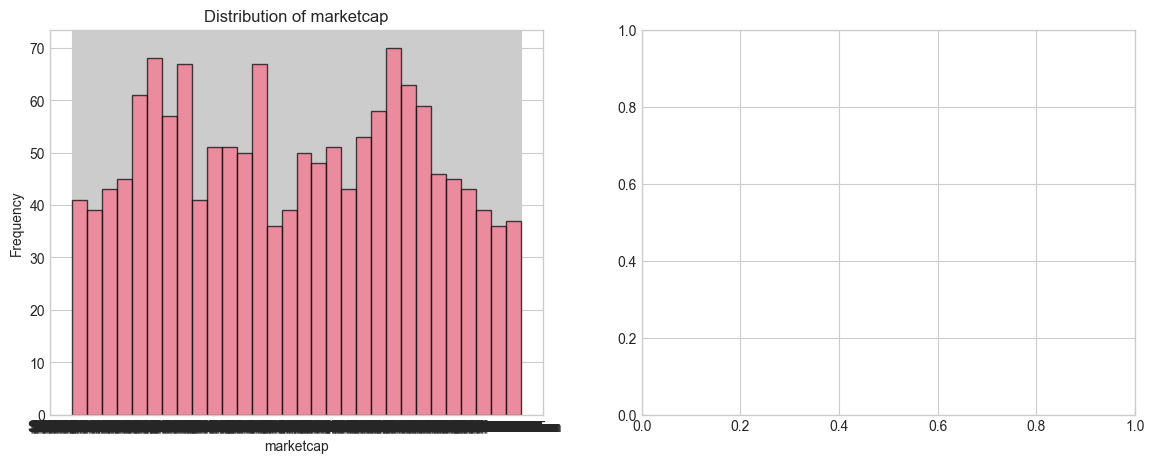

In [64]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [28]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

duplicate_rows = df.duplicated().sum()
total_rows = len(df)
percent_duplicates = (duplicate_rows/total_rows)


print(f"Duplicate rows: {duplicate_rows} {percent_duplicates}")


Duplicate rows: 0 0.0


In [29]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

null_columns = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100


missing_df = pd.DataFrame({'Missing Count': null_columns, 'Missing %': null_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by= 'Missing %', ascending=False)

print(f"{missing_df}")

                   Missing Count  Missing %
operating-margin             195  13.000000
pe-ratio                      32   2.133333
ps-ratio                      15   1.000000
total-debt                    14   0.933333
marketcap                      3   0.200000
net-assets                     3   0.200000
earnings                       2   0.133333
Country                        1   0.066667
revenue                        1   0.066667
total-assets                   1   0.066667
total-liabilities              1   0.066667


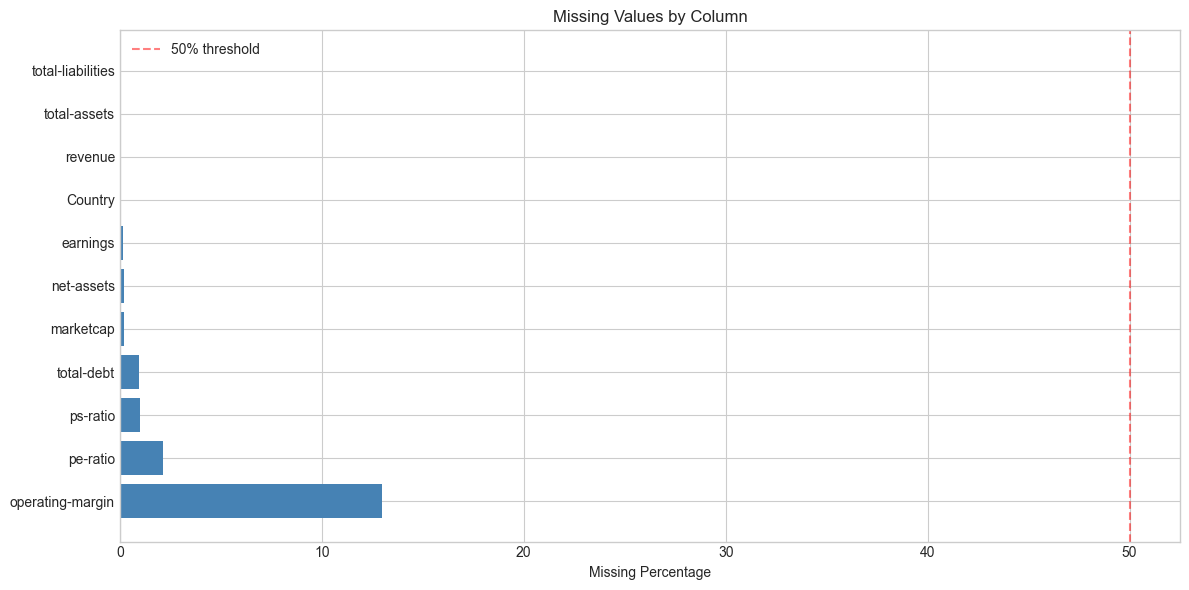

In [30]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**
- Is your target variable normally distributed or skewed?
- Are there any obvious outliers in the target?
- How much missing data do you have to deal with?
- Are there any duplicate rows?
- Any surprises or interesting findings?

**Your observations:**

Based on my initial exploration of the data I believe that my target variable might be more skewed towards commpanies in the billion dollar marketcap with little representation of small cap companies. There are a few outliers in the target, possibly start up size companies with a low million dollar marketcap. For my target I only have 4 missing data points and in my features I have a few missing data points, but overall I have data that I can fill in with the average or completely drop if necessary. Operating Margin is my feature with the most missing values with 195 missing, nearly 13% missing from that column. I have no duplicate rows or columns, the most interesting finding so far is that my target is an object and needs to be converted to a float and scaled. 

---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [71]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
# 2. Get the column names as a list with .columns.tolist()
# 3. Remove TARGET from the list if it's in there
# 4. Print the count and list of numerical features
#
# Store result in: numerical_cols

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove(TARGET)
numerical_cols.remove('log_revenue')
numerical_cols.remove('log_tot_assets')
numerical_cols.remove('log_earnings')
numerical_cols.remove('log_tot_liabilities')
numerical_cols.remove('log_tot_debt')
numerical_cols.remove('log_net_assets')
numerical_cols.remove('log_Target')
numerical_cols.remove('Industry_Technology')
numerical_cols.remove('Industry_Food')  
numerical_cols.remove('Industry_Insurance')
numerical_cols.remove('Industry_Oil&Gas')
numerical_cols.remove('Industry_Pharmaceuticals')
numerical_cols.remove('Industry_Real Estate')
numerical_cols.remove('Industry_Retail')
numerical_cols.remove('Country_India')
numerical_cols.remove('Country_Japan')
numerical_cols.remove('Country_UK')
numerical_cols.remove('Country_USA')
numerical_cols.remove('Country_Other')
print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")



Numerical features (9): ['revenue', 'earnings', 'operating-margin', 'total-assets', 'total-liabilities', 'total-debt', 'net-assets', 'pe-ratio', 'ps-ratio']


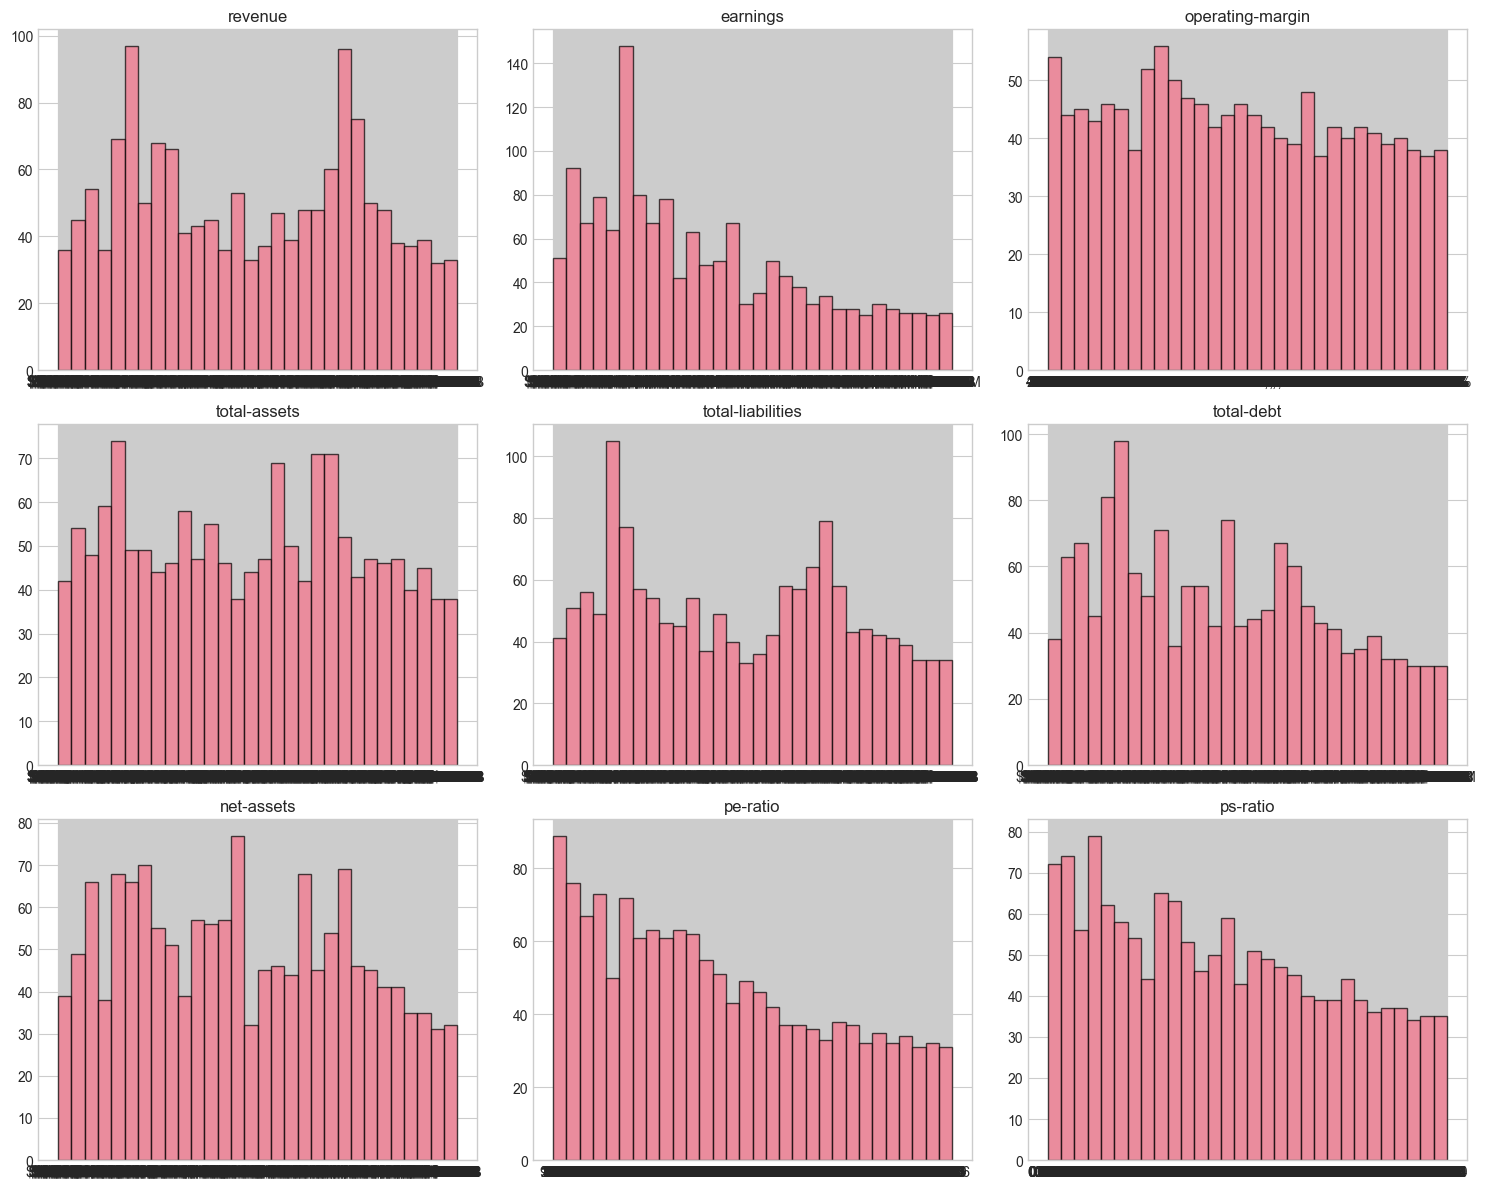

In [72]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [73]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
# 2. Get the column names as a list
# 3. Print the count and list of categorical features
# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
#
# Store result in: categorical_cols

categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    print(f"Categorical features ({len(categorical_cols)}) : {categorical_cols}")
    print(f"Unique values: {df_clean[col].unique()}")
    print(f"Value counts: {df_clean[col].value_counts().head(10)}")

In [74]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

No categorical columns with ≤10 unique values to plot.


### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

In [75]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 8]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

No suitable categorical columns for this analysis.


### 4.4 Correlation Analysis

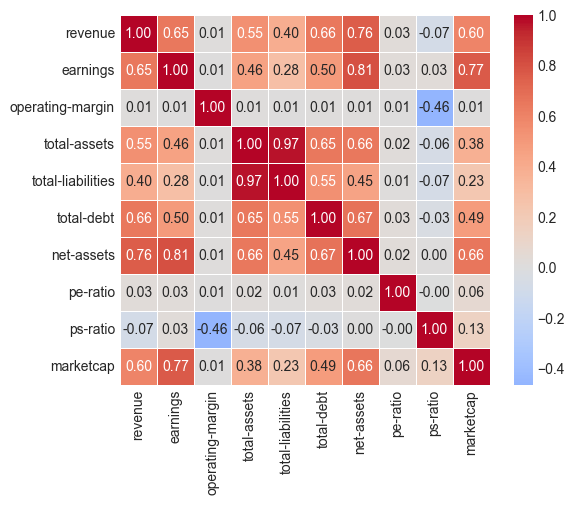

In [76]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

cor_columns = numerical_cols + [TARGET]
correlation_matrix = df_clean[cor_columns].corr()
correlation_matrix = sns.heatmap(correlation_matrix, 
            annot = True, 
            cmap= 'coolwarm', 
            center= 0, 
            fmt = '.2f', 
            square= True, 
            linewidths= 0.5)



In [77]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

target_correlations = correlation_matrix[TARGET]
target_correlations = target_correlations.drop(TARGET)  # Remove the correlation of TARGET with itself
target_correlations = target_correlations.sort_values(ascending=False)  # Sort in descending order
print(target_correlations)
strong_correlations = target_correlations[abs(target_correlations) > 0.5]  # Identify strong correlations
print("\nStrong correlations:")
print(strong_correlations)

TypeError: 'Axes' object is not subscriptable

In [78]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

NameError: name 'target_correlations' is not defined

<Figure size 1000x600 with 0 Axes>

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

In [79]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

NameError: name 'target_correlations' is not defined

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

In [ ]:
# YOUR ADDITIONAL EDA CODE HERE
# Add as many cells as you need - don't be limited by this template!



In [ ]:
# More exploration...



**What additional insights did you discover?**

[Describe any additional findings from your custom exploration]

### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target?
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**

The features that have the highest correlation with my Target turned out to be Revenue, Earnings, Net-Assets, and Total-Debt. These correlations make sense given the more money a company earns, the higher the value of that company. Total-Debt also makes sense given the more debt a company has, the higher its risk of stability. Companies with higher debt than cashflow have lower valuations. Some of the features that seem to be unimportant to our target are "Operating Margin", "Total-Assets", and "Total-Liabilities". I wont use Total assets and liabilities because we have "Net-Assets" which is the difference between both and has a higher correlation with the Target. I was surprised to find that "PE-Ratio" and "PS-Ratio" had a low correlation with the Target. However, it makes sense given that they are "backward" looking metrics meaning its based on past earnings/sales. In conclusion, I do believe that these can be very useful metrics when used in conjuction with other features. 

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [37]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

df_clean = df.copy()


print(f"Starting shape: {df_clean.shape}")

Starting shape: (1500, 15)


In [38]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns 
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: []

3. High cardinality (>100 unique): ['Company', 'Company Path', 'marketcap', 'revenue', 'earnings', 'operating-margin', 'total-assets', 'total-liabilities', 'total-debt', 'net-assets', 'pe-ratio', 'ps-ratio']

4. Low variance (>95% same value): []


In [39]:
# Drop columns
# TODO: Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [ 'Company' , 'Company Path', 'employees']

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

Dropped 3 columns: ['Company', 'Company Path', 'employees']
New shape: (1500, 12)


**Explain which columns you dropped and why:**

The columns that I dropped are "Company", "Company Path", and "Employees". I chose the Company name column because it is not important for the Target we are trying to predict. Company Path is not important because I don't need the URL. Lastly, the number of employees a company has is not imporant for trying to predict a companies Market Cap. 

### 5.2 Handle Duplicate Rows

In [40]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
# 3. Store the row count after
# 4. Print how many duplicates were removed

Before_removing_duplicates = len(df_clean)
df_clean = df_clean.drop_duplicates()
After_removing_duplicates = len(df_clean)

print(f"Duplicates Removed: {Before_removing_duplicates - After_removing_duplicates}")

Duplicates Removed: 0


### 5.3 Handle Missing Values

In [41]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
operating-margin     195
pe-ratio              32
ps-ratio              15
total-debt            14
marketcap              3
net-assets             3
earnings               2
Country                1
revenue                1
total-assets           1
total-liabilities      1
dtype: int64


In [ ]:
                                                    # I insterted this cell here first because I wanted to convert my numbers before doing any feature engineering or encoding.
def convert_numbers_billions(value):                # I created this function to clean and convert my numbers to floats in the Billions.
    if pd.isna(value):                              # I chose to create a function because its reusable and I can apply it to all of my features that need to be converted.
        return np.nan
    if isinstance(value, (int, float)):
        return float(value)

    value = value.replace("$", "").strip().lower()

    if any(x in value for x in ["trillion", "t"]):
        return float(value.replace("trillion", "").replace("t", "").strip()) * 1000
    elif any(x in value for x in ["billion", "b"]):
        return float(value.replace("billion", "").replace("b", "").strip())
    elif any(x in value for x in ["million", "m"]):
        return float(value.replace("million", "").replace("m", "").strip()) / 1000
    else:
        return float(value)

In [ ]:
# I am converting/transforming my feartures to Billions, Removing "$", New Dtype Float
df_clean[TARGET] = df_clean[TARGET].apply(convert_numbers_billions)
df_clean['revenue'] = df_clean['revenue'].apply(convert_numbers_billions)
df_clean['earnings'] = df_clean['earnings'].apply(convert_numbers_billions)
df_clean['total-assets'] = df_clean['total-assets'].apply(convert_numbers_billions)
df_clean['total-liabilities'] = df_clean['total-liabilities'].apply(convert_numbers_billions)
df_clean['total-debt'] = df_clean['total-debt'].apply(convert_numbers_billions)
df_clean['net-assets'] = df_clean['net-assets'].apply(convert_numbers_billions)

In [44]:
def convert_to_decimal(value):       # I created this function to cleanup "Operating Margin", remove %, Rmove ",", and conver to Decimal  
    cleaned_value = str(value).strip().replace('%', '').replace(',', '')
    decimal_value = float(cleaned_value) / 100
    return decimal_value

In [ ]:
# I am converting "Operating Margin" to Decimal, Removing "%", Removing ",", New Dtype Float
df_clean['operating-margin'] = df_clean['operating-margin'].apply(convert_to_decimal) 

In [46]:
# Let's visualize DF_Clean after converting  the numbers to Billions in the DataFrame.
print(df_clean.head())

     Industry Country  marketcap  revenue  earnings  operating-margin  \
0  Technology     USA    1966.00   574.78     40.73           -0.0115   
1  Technology  Taiwan      64.75   198.32      6.16            0.0255   
2  Technology   China      42.50   152.48      4.91            0.0255   
3  Technology     USA     170.42    61.85      8.69            0.0308   
4  Technology   Japan      21.53    59.64      3.17            0.0487   

   total-assets  total-liabilities  total-debt  net-assets pe-ratio ps-ratio  
0        527.85             325.97      135.61      201.87     96.5     3.42  
1        128.40              73.44       30.73       54.95     16.1   0.3255  
2         86.18              44.82        9.75       41.35     13.7   0.2839  
3        135.24             112.62       59.93       22.61     24.4     2.76  
4         63.21              32.29       11.30       30.92     7.18   0.3597  


In [47]:
# Handle missing values
# TODO: Add your missing value handling code here
# 
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

df_clean['operating-margin'] = df_clean['operating-margin'].fillna(df_clean['operating-margin'].median())
df_clean['total-debt'] = df_clean['total-debt'].fillna(df_clean['total-debt'].median())
df_clean = df_clean.dropna(subset=[TARGET])
df_clean = df_clean.dropna(subset = ['ps-ratio'])
df_clean = df_clean.dropna(subset = ['pe-ratio'])
df_clean = df_clean.dropna(subset = ['net-assets'])
df_clean = df_clean.dropna(subset = ['earnings'])
df_clean = df_clean.dropna(subset = ['Country'])
df_clean = df_clean.dropna(subset = ['revenue'])
df_clean = df_clean.dropna(subset = ['total-assets'])
df_clean = df_clean.dropna(subset = ['total-liabilities'])


In [48]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

Before handling the missing values, I decided to convert all my features to Billions by creating a function to convert those values. I also created a function to convert the Operating Margin column to a decimal and a float. Converting the columns before handling the missing values and moving forward in the EDA made sense to me because without converting the numbers I would not be able to fill columns, continue getting error codes, and run into other problems in the EDA. 

After converting the numbers, I then moved on to the missing value portion. My features with the most missing values were "Operating Margin" and "Total Debt". For those columns I chose to fill the missing values with the median because I am dealing with highly skewed numbers, therefore, using the median would be a more accurate representation of the company data. The rest of my features didnt have many missing values so I chose to drop the missing values in those columns. For my Target, I only had 3 missing values so I decided it would make sense to drop those missing values as well.

### 5.4 Handle Outliers (if needed)

In [49]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
marketcap: 179 outliers (12.3%) | bounds: [-23.79, 44.38]
revenue: 172 outliers (11.8%) | bounds: [-16.18, 30.02]
earnings: 198 outliers (13.6%) | bounds: [-1.92, 3.31]
operating-margin: 220 outliers (15.1%) | bounds: [-0.17, 0.35]
total-assets: 193 outliers (13.3%) | bounds: [-32.36, 60.09]
total-liabilities: 212 outliers (14.6%) | bounds: [-19.42, 35.56]
total-debt: 178 outliers (12.2%) | bounds: [-8.08, 14.64]
net-assets: 163 outliers (11.2%) | bounds: [-11.44, 21.35]


In [ ]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

# YOUR CODE HERE:



**Explain your outlier handling strategy (or why you kept them):**

I decided to keep the outliers because dealing with company data gives a wide range of numbers and those outliers are still an accurate representation of many companies publicly traded on the stock market. For example, a company like Amazon will have much higher numbers than most companies because of the Scale of the company and revenue drivers like AWS, the grocery business along with their e-commerce business. 

### 5.5 Data Type Corrections

In [50]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
Industry              object
Country               object
marketcap            float64
revenue              float64
earnings             float64
operating-margin     float64
total-assets         float64
total-liabilities    float64
total-debt           float64
net-assets           float64
pe-ratio              object
ps-ratio              object
dtype: object


In [ ]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
# Examples:
# df_clean['year'] = df_clean['year'].astype(int)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category'] = df_clean['category'].astype('category')

df_clean['Country'] = df_clean['Country'].astype('category')
df_clean['Industry'] = df_clean['Industry'].astype('category')
df_clean['pe-ratio'] = pd.to_numeric(df_clean['pe-ratio'], errors='coerce')
df_clean['ps-ratio'] = pd.to_numeric(df_clean['ps-ratio'], errors='coerce')

df_clean.info() # Check final info after fixing final data types.


<class 'pandas.core.frame.DataFrame'>
Index: 1455 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Industry           1455 non-null   category
 1   Country            1455 non-null   category
 2   marketcap          1455 non-null   float64 
 3   revenue            1455 non-null   float64 
 4   earnings           1455 non-null   float64 
 5   operating-margin   1455 non-null   float64 
 6   total-assets       1455 non-null   float64 
 7   total-liabilities  1455 non-null   float64 
 8   total-debt         1455 non-null   float64 
 9   net-assets         1455 non-null   float64 
 10  pe-ratio           1442 non-null   float64 
 11  ps-ratio           1453 non-null   float64 
dtypes: category(2), float64(10)
memory usage: 130.7 KB


## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [52]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

df_clean['log_revenue'] = np.log1p(df_clean['revenue'])
df_clean['log_earnings'] = np.log1p(df_clean['earnings'])
df_clean['log_tot_assets'] = np.log1p(df_clean['total-assets'])
df_clean['log_tot_liabilities'] = np.log1p(df_clean['total-liabilities'])
df_clean['log_tot_debt'] = np.log1p(df_clean['total-debt'])
df_clean['log_net_assets'] = np.log1p(df_clean['net-assets'])
df_clean['log_Target'] = np.log1p(df_clean[TARGET])

print(df_clean.head())

     Industry Country  marketcap  revenue  earnings  operating-margin  \
0  Technology     USA    1966.00   574.78     40.73           -0.0115   
1  Technology  Taiwan      64.75   198.32      6.16            0.0255   
2  Technology   China      42.50   152.48      4.91            0.0255   
3  Technology     USA     170.42    61.85      8.69            0.0308   
4  Technology   Japan      21.53    59.64      3.17            0.0487   

   total-assets  total-liabilities  total-debt  net-assets  pe-ratio  \
0        527.85             325.97      135.61      201.87     96.50   
1        128.40              73.44       30.73       54.95     16.10   
2         86.18              44.82        9.75       41.35     13.70   
3        135.24             112.62       59.93       22.61     24.40   
4         63.21              32.29       11.30       30.92      7.18   

   ps-ratio  log_revenue  log_earnings  log_tot_assets  log_tot_liabilities  \
0    3.4200     6.355726      3.731220        6.2

**Explain your new features:**

In the feature engineering section I decided to Log Transform my data. Since I am handling company data/financial metrics, Log transformation will help reduce how right skewed the numbers are. The numbers in the data frame range from the high hundreds of thousands up to trillions of dollars. Log Tansformation converts these exponential numbers to a more linear relationship to stabalize variance and help make easier predictions.  

### 6.2 Encode Categorical Variables

In [53]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols



cat_cols = df_clean.select_dtypes(include = ['object', 'category'])
print(f"{cat_cols.nunique()} ")


Industry     8
Country     53
dtype: int64 


In [54]:
# Before Encoding our categorical columns I want to use the Binning method for my Country feature
# Country has 52 unique values, Use the most frequent countries and create an OTHER category.
# Print out the Value_Counts after

top_countries = ['USA', 'China', 'Japan', 'UK', 'India' ]
country_binned = []

for country in df_clean['Country']:
    if country in top_countries:
        country_binned.append(country)
    else:
        country_binned.append('Other') 

df_clean['Country'] = country_binned
print(df_clean['Country'].value_counts())

Country
USA      602
Other    548
India     98
Japan     75
China     67
UK        65
Name: count, dtype: int64


In [55]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])


df_clean = pd.get_dummies(df_clean, columns = ['Industry'], drop_first=True, dtype=int) # Added dtype = int
df_clean = pd.get_dummies(df_clean, columns = ['Country'], drop_first=True, dtype=int)  # True/False = 0's/1's





In [56]:
# Check/Visualization after encoding categorical features
print(df_clean.head())

   marketcap  revenue  earnings  operating-margin  total-assets  \
0    1966.00   574.78     40.73           -0.0115        527.85   
1      64.75   198.32      6.16            0.0255        128.40   
2      42.50   152.48      4.91            0.0255         86.18   
3     170.42    61.85      8.69            0.0308        135.24   
4      21.53    59.64      3.17            0.0487         63.21   

   total-liabilities  total-debt  net-assets  pe-ratio  ps-ratio  log_revenue  \
0             325.97      135.61      201.87     96.50    3.4200     6.355726   
1              73.44       30.73       54.95     16.10    0.3255     5.294912   
2              44.82        9.75       41.35     13.70    0.2839     5.033570   
3             112.62       59.93       22.61     24.40    2.7600     4.140751   
4              32.29       11.30       30.92      7.18    0.3597     4.104955   

   log_earnings  log_tot_assets  log_tot_liabilities  log_tot_debt  \
0      3.731220        6.270705         

**Explain your encoding strategy:**

- My 2 categorical features that needed to be encoded were "Industry" and "Country". My strategy for Country was more robust than simply just One-Hot-Encoding new columns for each Country. Before one hot encoding this feature I decided to use the binning method. My most frequently occuring countries were "USA, China, Japan, UK, & India". If the Country was not one of those I decided to "Bin" them into an "Other" category and then performed One-Hot-Encoding on this feature. 

- One-Hot-Encoding for "Industry" was pretty straight-forward since there were only 8 unique items in this category. We use One-Hot-Encoding when natural order does not exist.


### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

In [ ]:
# YOUR ADDITIONAL FEATURE ENGINEERING CODE HERE
# Add as many cells as you need!



**Explain your additional feature engineering:**

[Describe any additional features you created and your reasoning]

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [57]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)
#
# Store in: numerical_features

numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()

numerical_features.remove(TARGET)

print("Numerical features and their ranges:")
for feature in numerical_features:
    min_val = df_clean[feature].min()
    max_val = df_clean[feature].max()
    range_val = max_val - min_val
    print(f"{feature}: Min={min_val}, Max={max_val}, Range={range_val}")

Numerical features and their ranges:
revenue: Min=-1.31, Max=648.12, Range=649.43
earnings: Min=-13.67, Max=236.96, Range=250.63
operating-margin: Min=-1474.05, Max=1.9386, Range=1475.9886
total-assets: Min=0.0263, Max=1638.0, Range=1637.9737
total-liabilities: Min=0.01456, Max=1464.0, Range=1463.98544
total-debt: Min=1e-05, Max=210.52, Range=210.51999
net-assets: Min=-15.15, Max=463.78, Range=478.92999999999995
pe-ratio: Min=-837.0, Max=901.0, Range=1738.0
ps-ratio: Min=-0.0999, Max=108.0, Range=108.0999
log_revenue: Min=0.0006198078794057442, Max=6.475617599458137, Range=6.474997791578732
log_earnings: Min=-3.912023005428145, Max=5.472102592319705, Range=9.38412559774785
log_tot_assets: Min=0.025960101669531634, Max=7.40184157874383, Range=7.375881477074298
log_tot_liabilities: Min=0.01445502096958444, Max=7.289610521451167, Range=7.275155500481583
log_tot_debt: Min=9.999950000333332e-06, Max=5.354319556663322, Range=5.354309556713321
log_net_assets: Min=-2.8134107167600355, Max=6.14

### 6.5 Final Sanity Checks

In [58]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 1,455 rows, 29 columns
   (Started with 1,500 rows, 15 columns)

2. Missing values: 67

3. Duplicate rows: 0

4. Target variable 'marketcap':
   - Min: 0.00
   - Max: 3179.00
   - Mean: 34.62

5. Data types:
   - Numerical: 29
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [59]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (1455, 29)

Columns (29):
['marketcap', 'revenue', 'earnings', 'operating-margin', 'total-assets', 'total-liabilities', 'total-debt', 'net-assets', 'pe-ratio', 'ps-ratio', 'log_revenue', 'log_earnings', 'log_tot_assets', 'log_tot_liabilities', 'log_tot_debt', 'log_net_assets', 'log_Target', 'Industry_Food', 'Industry_Insurance', 'Industry_Oil&Gas', 'Industry_Pharmaceuticals', 'Industry_Real Estate', 'Industry_Retail', 'Industry_Technology', 'Country_India', 'Country_Japan', 'Country_Other', 'Country_UK', 'Country_USA']

Data types:
marketcap                   float64
revenue                     float64
earnings                    float64
operating-margin            float64
total-assets                float64
total-liabilities           float64
total-debt                  float64
net-assets                  float64
pe-ratio                    float64
ps-ratio                    float64
log_revenue                 float64
log_earnings                float64


In [60]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

**Summary of changes:**

When I began the EDA, I was having trouble with the visiualizations because my data in the dataframe were "strings" and not the correct data types we use to visualize our data. Initially, I kept getting error messages or empty plots. My plan of attack at this point was to begin with converting my data to ready to use numbers so that I could actually visualize the correlation matrix, Target plots, etc. I converted both my features and my Target from 'strings" with "$", the words "Trillion" or "Billion", and "%" all to digestible numbers in the Billions. Then, I did Log Transformations on these numbers to reduce the skewness of the numbers and make them more ML ready to train my mddel. I Dropped the columns "Company" and "Company Path" because they wouldnt be useful for the prediction I am trying to make. I transformed "Industry" and "Country" to categorical features and One-Hot-encoded them to make them ML ready. After completing all of the data cleaning and feature engineering I saved my "DF_Clean" and went back to the previous section because now with the transformed numbers I wanted to go back to see the visualizations and correlation matrix to see what else we could learn from the visualizations. 

**Final feature list for modeling:**

After the EDA, Data Cleaning, and Feature Engineering I ended with 29 columns(Features).
Final List For Modeliing
-Revenue(log)
-Earnings(log)
-Net Assets(log)
-Total Debt(log)
-PE Ratio(log)
-Country(One-Hot-Encoded)
-Industry(One-Hot-Encoded)

---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---